# Evaluate Essay using Lang Graph

Evaluate an essay based on three key criteria using an LLM:

1. **Clarity of Thought (COT)**

   * Evaluate how clearly the ideas, arguments, and thoughts are presented.
   * Provide detailed textual feedback.
   * Assign a score between **1 and 10**.

2. **Depth of Analysis (DOA)**

   * Evaluate the depth, reasoning, supporting arguments, examples, and insights in the essay.
   * Provide detailed textual feedback.
   * Assign a score between **1 and 10**.

3. **Language**

   * Evaluate grammar, vocabulary, sentence structure, readability, and overall language quality.
   * Provide detailed textual feedback.
   * Assign a score between **1 and 10**.

### Final Evaluation

The LLM should generate a final evaluation based on the feedback from all three criteria.

**Final Score = (COT Score + DOA Score + Language Score) / 3**

The final output should include:

* **Clarity of Thought:** Score + feedback
* **Depth of Analysis:** Score + feedback
* **Language:** Score + feedback
* **Overall Feedback:** Consolidated evaluation
* **Final Score:** Average score out of 10

**Techniques Used**<br>
* **Parallel Workflow** – Evaluate all three criteria simultaneously to reduce execution time. <br>
* **Structured Output** – Ensure each LLM evaluation returns a consistent score and feedback format. <br>
* **Reducer Function**– Combine the outputs from all parallel evaluation tasks and calculate the final average score.


In [183]:
#local ollama
from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma3:4b")
response = model.invoke("the capital of India? in one word")
print(response.content)

Delhi


In [184]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from google import genai
import os
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
import operator

#pip install langchain_google_genai

## Reducer Function

Since all three evaluation nodes—**Clarity of Thought (COT)**, **Depth of Analysis (DOA)**, and **Language**—run in parallel, their individual scores need to be collected into a single list.

For example:

`[8] + [7] + [6] → [8, 7, 6]`

If multiple parallel nodes update the same state field without a reducer, one result may overwrite another. To prevent this, we use the **`add` reducer function**.

```python
from typing import TypedDict, Annotated
from operator import add

class EssayState(TypedDict):
    essay: str
    scores: Annotated[list[int], add]
```
`Annotated` tells LangGraph:

> **"When these parallel updates arrive, don't overwrite them. Use this reducer to merge them."**

### Key Concept

**`Annotated` + Reducer = Define how LangGraph should merge multiple updates to the same state field.**

In [185]:
class esssaystate(TypedDict):
    essay: str
    cot_feedback :str
    DOA_feedback: str
    language_feedback :str

    overall_feedback:str
    individual_score:Annotated[list[int],operator.add]
    avg_score:float
    

In [186]:
class Evaluation(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay")
    score: int = Field(description="Score between 1 and 10")

In [187]:
structured_model = model.with_structured_output(Evaluation)

In [188]:
essay = """
Artificial intelligence is transforming the modern workplace.
It helps organizations automate repetitive tasks, improve
decision making, and increase productivity.

However, the growth of AI also creates challenges for employees.
Workers need to continuously develop new technical skills.
Organizations should therefore invest in employee training and
create opportunities for people to work together with AI systems.

AI should not be viewed only as a replacement for human workers.
Instead, it should be considered a technology that can augment
human capabilities and help people perform their jobs more
effectively.
"""

In [190]:
#test llm
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt)

Evaluation(feedback="This is a solid, clear, and concise essay on the impact of AI in the workplace. It presents a balanced perspective, acknowledging both the benefits and challenges. Here's a breakdown of the feedback, categorized for clarity:", score=75)

In [191]:
def evaluate_language(state:esssaystate):
     essay=state['essay']
     prompt=f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
     output=structured_model.invoke(prompt)
     return {"language_feedback": output.feedback,"individual_score": [output.score]}

In [192]:
def evaluate_cot(state:esssaystate):
     essay=state['essay']
     prompt=f'Evaluate the clarity of through of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
     output=structured_model.invoke(prompt)
     return {"cot_feedback": output.feedback,"individual_score": [output.score]}

In [193]:
def evaluate_DOA(state:esssaystate):
     essay=state['essay']
     prompt=f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
     output=structured_model.invoke(prompt)
     return {'DOA_feedback':output.feedback ,'individual_score':[output.score]}

In [194]:
def final_evaluation(state:esssaystate):
     essay=state['essay']
     prompt=f'''Based on the following feedbacks create a summarized feedback \n language feedback -{state['language_feedback']} \n 
              depth of analysis - {state['DOA_feedback']}' \n clarity of through -{state['cot_feedback']}'''
     output=model.invoke(prompt).content
     avg_score=round(sum(state['individual_score'])/len(state['individual_score']),2)
     return {'overall_feedback':output ,'avg_score':avg_score}

In [195]:
graph=StateGraph(esssaystate)

#node
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_cot',evaluate_cot)
graph.add_node('evaluate_DOA',evaluate_DOA)
graph.add_node('final_evaluation',final_evaluation)

#edge
graph.add_edge(START,'evaluate_cot')
graph.add_edge(START,'evaluate_DOA')
graph.add_edge(START,'evaluate_language')

graph.add_edge('evaluate_cot','final_evaluation')
graph.add_edge('evaluate_DOA','final_evaluation')
graph.add_edge('evaluate_language','final_evaluation')

graph.add_edge('final_evaluation',END)

#compile the graph
workflow=graph.compile()

#execute the graph
initial_state = {'essay':essay}
final_state=workflow.invoke(initial_state)
print(final_state)


{'essay': '\nArtificial intelligence is transforming the modern workplace.\nIt helps organizations automate repetitive tasks, improve\ndecision making, and increase productivity.\n\nHowever, the growth of AI also creates challenges for employees.\nWorkers need to continuously develop new technical skills.\nOrganizations should therefore invest in employee training and\ncreate opportunities for people to work together with AI systems.\n\nAI should not be viewed only as a replacement for human workers.\nInstead, it should be considered a technology that can augment\nhuman capabilities and help people perform their jobs more\neffectively.\n', 'cot_feedback': "This is a solid, concise introductory piece about AI in the workplace. It effectively lays out the core arguments – the benefits and the challenges – in a clear and accessible way. Here's a breakdown of my feedback:\n\n**Strengths:**\n\n* **Clear and Direct:** The language is straightforward and easy to understand. There’s no jargon,

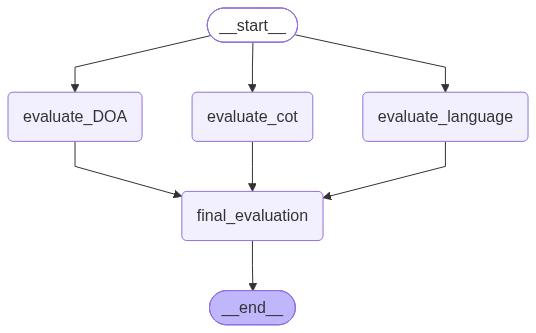

In [196]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())